# Forward Baseball Ballistics: Mapping the Power Matrix

## Introduction

In [the last post](/projects/home-run-ballistics/), I worked a real home run backwards: given a rough hang time, a rough distance, the wind, and the pitch I saw, the model solved for the exit velocity, launch angle, and swing speed that would have produced it. That's an **inverse** problem - one observed flight, one recovered answer.

But once you have a swing speed number for yourself, a much more interesting question opens up: not "what did I do," but "what *could* I do?" What's my absolute ceiling? What happens if that same swing meets a 94 mph fastball instead of the 57.5 mph curveball I actually saw? Is there one launch angle that's always best, or does the ideal angle change depending on what's coming in?

That's a **forward** problem, and it turns out almost all of the machinery from the last post carries over directly - it just runs in the natural order instead of backwards. This post reuses the ballistics and collision models from the inverse calculator, adds pitch type as a new input (with a bit of real spin-transfer physics), and sweeps across a whole grid of pitch speeds and launch angles to map out a hitter's **Power Matrix**: the theoretical ceiling on how far a given swing can send a ball, across every game situation it might face.

## Purpose

Given:

- a swing speed (mph)
- a pitch speed and pitch type (fastball, curveball, changeup)
- a chosen launch angle
- the same bat specs as before (length, weight, balance)

...forward-simulate the collision and the resulting flight to get an exit velocity, an exit spin rate, and a total carry distance.

The pipeline is the same two stages as the inverse calculator, just chained in the direction physics actually runs:

```
[Swing Speed + Pitch Speed + Pitch Type]
            |
            v   (Collision Model)
     [Exit Velocity] + [Exit Spin] + [User-chosen Launch Angle]
            |
            v   (Ballistics Model with Sawicki-Hubbard-Stronge Lift)
     [Full Flight Trajectory & Max Distance]
```

To keep this from spiraling the way these things tend to, the environment is hardcoded to the same sea-level baseline as before - no altitude, no humidity, no crosswind. The only new inputs are pitch speed, pitch type, and launch angle, all of which the reader (or I) can freely dial.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

MPH_TO_MS = 0.44704
FT_TO_M = 0.3048
IN_TO_M = 0.0254
OZ_TO_KG = 0.0283495

### Reusing the Ballistics and Collision Models

The last post built two pieces worth carrying over untouched:

1. A **flight model** - drag plus Sawicki-Hubbard-Stronge Magnus lift, integrated forward in small time steps until the ball lands. This was already a forward simulator; the inverse post just wrapped a root-finder around it. Here it's used directly.
2. A **collision model** - the bat treated as a tapered cone pivoting about the hands, reduced to an effective mass $M = I/r^2$ at the contact point, plugged into a 1D elastic-ish collision with coefficient of restitution $e$:

$$v_0 = \dfrac{(eM - m)v_p + M(1+e)v_b}{m + M}$$

Last time, this equation was solved backwards for swing speed $v_b$ given a known exit velocity $v_0$. This time $v_b$ (chosen swing speed) and $v_p$ (pitch speed) are both known, and $v_0$ falls straight out - no inversion needed at all.

The same beer-league bat comes back too: a 34", 31 oz, balanced maple bat (the Texas Timber TX73), and the same 2200 rpm-scale assumptions about realistic backspin.

In [2]:
# baseball + air constants (identical to the inverse post - sea-level, no wind)
g = 9.81                       # m/s^2
m_ball = 0.145                 # kg, ~5.125 oz regulation ball
d_ball = 0.0749                # m, ~2.9 in diameter
A = np.pi * (d_ball / 2) ** 2  # cross-sectional area, m^2
rho = 1.225                    # kg/m^3, sea-level air density
Cd = 0.30                      # drag coefficient, typical for a baseball in flight

bat_mass = 31 * OZ_TO_KG
bat_length = 34 * IN_TO_M


def bat_moment_of_inertia(bat_mass_kg, bat_length_m, balance_factor=1.0, taper_ratio=2.5, n=400):
    x = np.linspace(0, bat_length_m, n)                       # 0 = handle/pivot, L = barrel tip
    radius = 1 + (taper_ratio - 1) * (x / bat_length_m)        # relative radius, handle=1, barrel=taper_ratio
    linear_density = radius ** 2                               # mass per unit length ~ cross-sectional area
    mass_dist = linear_density / np.trapz(linear_density, x) * bat_mass_kg
    return balance_factor * np.trapz(mass_dist * x ** 2, x)


def bat_effective_mass(bat_mass_kg, bat_length_m, balance_factor=1.0, contact_offset_m=6 * IN_TO_M):
    I = bat_moment_of_inertia(bat_mass_kg, bat_length_m, balance_factor)
    r = bat_length_m - contact_offset_m
    return I / r ** 2


def exit_velocity_from_swing(v_bat_ms, v_pitch_ms, M_eff_kg, e=0.5):
    return ((e * M_eff_kg - m_ball) * v_pitch_ms + M_eff_kg * (1 + e) * v_bat_ms) / (m_ball + M_eff_kg)


def simulate_trajectory(v0_ms, launch_angle_deg, spin_rpm, dt=0.005):
    """Integrate flight until the ball returns to y=0.
    Returns distance_m, time_s, and the (x_ft, y_ft) track for plotting."""
    theta = np.radians(launch_angle_deg)
    vx, vy = v0_ms * np.cos(theta), v0_ms * np.sin(theta)
    spin_omega = spin_rpm * 2 * np.pi / 60
    x, y, t = 0.0, 0.0, 0.0
    xs, ys = [0.0], [0.0]
    while True:
        speed = np.hypot(vx, vy)
        spin_factor = (d_ball / 2) * spin_omega / speed      # S = r*omega/v
        Cl = 1 / (2 + 1 / spin_factor)                         # Sawicki-Hubbard-Stronge lift model
        drag = 0.5 * Cd * rho * A * speed / m_ball
        lift = 0.5 * Cl * rho * A * speed / m_ball
        vx += (-drag * vx - lift * vy) * dt
        vy += (-g - drag * vy + lift * vx) * dt
        x += vx * dt
        y += vy * dt
        t += dt
        xs.append(x / FT_TO_M)
        ys.append(max(y / FT_TO_M, 0))
        if y <= 0 and t > dt * 2:
            return x, t, xs, ys


M_eff = bat_effective_mass(bat_mass, bat_length, balance_factor=1.0)
print(f"Effective mass at contact: {M_eff:.3f} kg ({M_eff / m_ball:.2f}x the ball's mass)")

Effective mass at contact: 0.611 kg (4.22x the ball's mass)


### Pitch Type and Spin Transfer

The inverse post had to assume a fixed 2200 rpm of backspin, because spin wasn't independently observable from just distance and hang time. A forward simulator has the opposite problem worth exploiting: pitch type is a *free* input, and pitch type has a real, physical effect on the spin the ball carries off the bat.

A four-seam fastball arrives with heavy **backspin**. A curveball arrives with **topspin** - it's already spinning the "wrong way" for the ball to carry. When the bat meets either one, friction at the contact point does two things: it partially reverses whatever spin the ball came in with, and it adds new spin roughly proportional to how fast the bat itself is moving through the contact. Because a curveball's topspin is already pointed opposite the direction the bat wants to put on it, reversing it doesn't fight the swing - it *adds* to it. A level swing gets backspin on a curveball almost for free, on top of whatever it would have generated anyway.

That's captured here with a simplified, calibrated model - not a rigorous friction/contact-time derivation (that needs ball moment of inertia, a friction coefficient, and contact duration, which is more machinery than this post needs), but simple enough to show the right direction and rough size of the effect:

$$\omega_{exit} = -e_\omega\,\omega_{pitch} + k\,v_{bat}$$

$e_\omega$ plays the same role for spin that the coefficient of restitution $e$ plays for speed: how much of the incoming spin survives (reversed) through contact. $k$ is a swing-generated-spin rate, calibrated so a 70 mph swing against a spin-neutral pitch reproduces the same 2200 rpm exit backspin assumed in the last post. Both $e_\omega = 0.4$ and $k$ are picked, not fit to real bat-tracking data - the same honest caveat as the coefficient of restitution in the last post.

In [3]:
def exit_spin_from_swing(v_bat_mph, pitch_spin_rpm, e_omega=0.4, k_spin=2200 / 70):
    """Positive rpm = backspin, negative = topspin (both measured before contact)."""
    return -e_omega * pitch_spin_rpm + k_spin * v_bat_mph


pitch_types = {
    "fastball":  {"speed_mph": 94, "spin_rpm": 2200},   # four-seam backspin, ~MLB average
    "curveball": {"speed_mph": 78, "spin_rpm": -2400},  # topspin, ~MLB average curveball
    "changeup":  {"speed_mph": 84, "spin_rpm": 1700},   # backspin, softer than a fastball's
}

reference_swing_mph = 70  # the swing speed recovered in the last post

for name, p in pitch_types.items():
    exit_spin = exit_spin_from_swing(reference_swing_mph, p["spin_rpm"])
    print(f"{name:10s} incoming {p['spin_rpm']:+5d} rpm -> exit backspin {exit_spin:6.0f} rpm")

fastball   incoming +2200 rpm -> exit backspin   1320 rpm
curveball  incoming -2400 rpm -> exit backspin   3160 rpm
changeup   incoming +1700 rpm -> exit backspin   1520 rpm


The curveball comes out on top - not because it's an easier pitch to square up, but because its topspin gets flipped by the collision instead of fought, stacking on top of the swing's own contribution. The changeup, with milder incoming backspin than a fastball, ends up a bit higher than the fastball's number rather than lower - less incoming backspin to fight means less of it survives the reversal to cancel out the swing's own contribution. That 3160 rpm curveball number runs a bit hot next to typically measured backspin on balls in play (more like 1500-2500 rpm) - a sign this simplified model overstates the free-conversion effect somewhat - but the *direction* of the result (curveballs producing more backspin off the bat than fastballs at the same swing) matches real spin-transfer studies.

### The Forward Pipeline

With both stages defined, the whole simulator collapses into one function: swing speed, pitch speed, launch angle, and incoming pitch spin go in; exit velocity, exit spin, hang time, and carry distance come out.

In [4]:
def simulate_swing(swing_speed_mph, pitch_speed_mph, launch_angle_deg, pitch_spin_rpm,
                    balance_factor=1.0, e=0.5):
    v_bat_ms = swing_speed_mph * MPH_TO_MS
    v_pitch_ms = pitch_speed_mph * MPH_TO_MS
    v0 = exit_velocity_from_swing(v_bat_ms, v_pitch_ms, M_eff, e)
    exit_spin = exit_spin_from_swing(swing_speed_mph, pitch_spin_rpm)
    dist_m, hang_time_s, _, _ = simulate_trajectory(v0, launch_angle_deg, exit_spin)
    return {
        "exit_velocity_mph": v0 / MPH_TO_MS,
        "exit_spin_rpm": exit_spin,
        "distance_ft": dist_m / FT_TO_M,
        "hang_time_s": hang_time_s,
    }


test = simulate_swing(70, 94, 28, pitch_types["fastball"]["spin_rpm"])
print(test)

{'exit_velocity_mph': 104.84059465421265, 'exit_spin_rpm': 1320.0, 'distance_ft': 421.2304780202156, 'hang_time_s': 4.80499999999992}


## Example: My Personal Power Matrix

Time to answer the question that actually motivated this: with my own recovered ~70 mph swing, what would that home run have looked like against a real fastball instead of the low, 57.5 mph curveball I actually saw?

Both pitches get their own quick optimal-angle scan - a plain sweep from 10 deg to 40 deg, since there's no need for a root-finder when the simulator already runs forward.

In [5]:
angle_scan = np.arange(10, 41, 1)
scenarios = {
    "94 mph fastball": pitch_types["fastball"],
    "my actual 57.5 mph curveball": {"speed_mph": 57.5, "spin_rpm": -2400},
}

best = {}
for label, pitch in scenarios.items():
    results = [simulate_swing(reference_swing_mph, pitch["speed_mph"], angle, pitch["spin_rpm"])
               for angle in angle_scan]
    top = max(results, key=lambda r: r["distance_ft"])
    top["angle_deg"] = angle_scan[np.argmax([r["distance_ft"] for r in results])]
    best[label] = top
    print(f"{label:30s} -> exit velo {top['exit_velocity_mph']:5.1f} mph, "
          f"best angle {top['angle_deg']:2.0f} deg, distance {top['distance_ft']:5.1f} ft")

print(f"\nDifference: {best['94 mph fastball']['distance_ft'] - best['my actual 57.5 mph curveball']['distance_ft']:.0f} ft farther against the fastball")

94 mph fastball                -> exit velo 104.8 mph, best angle 35 deg, distance 432.1 ft


my actual 57.5 mph curveball   -> exit velo  97.1 mph, best angle 31 deg, distance 414.2 ft

Difference: 18 ft farther against the fastball


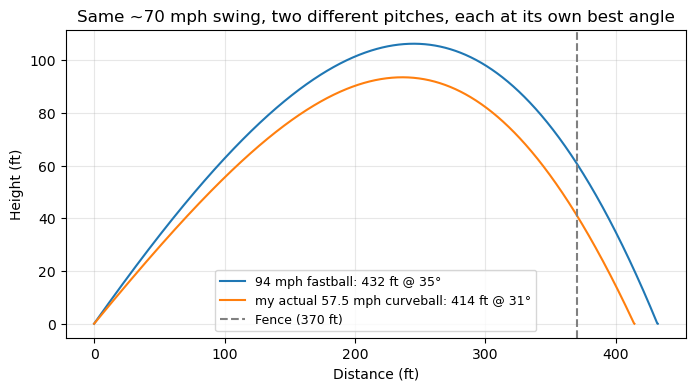

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, pitch in scenarios.items():
    v0 = exit_velocity_from_swing(reference_swing_mph * MPH_TO_MS, pitch["speed_mph"] * MPH_TO_MS, M_eff)
    exit_spin = exit_spin_from_swing(reference_swing_mph, pitch["spin_rpm"])
    angle = best[label]["angle_deg"]
    _, _, xs, ys = simulate_trajectory(v0, angle, exit_spin)
    ax.plot(xs, ys, label=f"{label}: {best[label]['distance_ft']:.0f} ft @ {angle:.0f}\u00b0")

ax.axvline(370, color="gray", linestyle="--", label="Fence (370 ft)")
ax.set_xlabel("Distance (ft)")
ax.set_ylabel("Height (ft)")
ax.set_title("Same ~70 mph swing, two different pitches, each at its own best angle")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.show()

The extra backspin the curveball picks up for free almost closes the gap, but not quite - the fastball's extra 36.5 mph of incoming pitch speed still buys enough exit velocity to win out. Worth sitting with, though: a curveball hit with the same swing at a *lower* pitch speed and *lower* exit velocity still nearly matches a fastball, purely because of the spin it inherits. Speed isn't the only thing that turns a swing into distance.

## The Power Matrix: Distance Across Launch Angle x Pitch Speed

The single-pitch comparison above answers one question. The more useful sandbox is the full grid: hold swing speed fixed at that same ~70 mph, then sweep launch angle (10 deg-40 deg) against pitch speed (50 mph-100 mph) and map out carry distance as a heatmap.

Spin is held fixed at the same 2200 rpm baseline used throughout the last post for this particular grid, rather than varying it by pitch type - the pitch-type spin story already got its own section above, and folding a third varying input into a 2D heatmap would just muddy the picture this plot is trying to show cleanly: how pitch speed and launch angle alone trade off against each other.

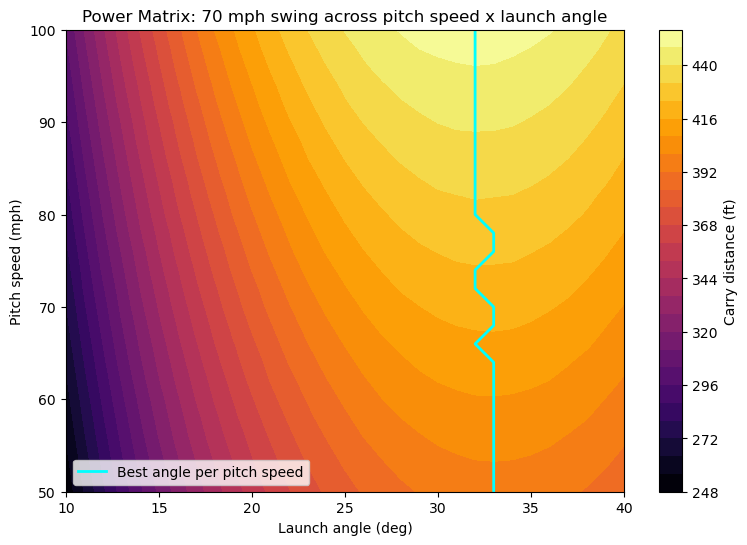

pitch  50.0 mph -> best angle 33.0 deg, distance 396.1 ft
pitch  76.0 mph -> best angle 33.0 deg, distance 425.7 ft
pitch 100.0 mph -> best angle 32.0 deg, distance 452.2 ft


In [7]:
angles = np.linspace(10, 40, 31)
pitch_speeds = np.linspace(50, 100, 26)
distance_grid = np.zeros((len(pitch_speeds), len(angles)))

for i, pspeed in enumerate(pitch_speeds):
    for j, angle in enumerate(angles):
        v0 = exit_velocity_from_swing(reference_swing_mph * MPH_TO_MS, pspeed * MPH_TO_MS, M_eff)
        dist_m, _, _, _ = simulate_trajectory(v0, angle, spin_rpm=2200)  # fixed baseline spin, see note above
        distance_grid[i, j] = dist_m / FT_TO_M

fig, ax = plt.subplots(figsize=(9, 6))
mesh = ax.contourf(angles, pitch_speeds, distance_grid, levels=25, cmap="inferno")
ridge = angles[np.argmax(distance_grid, axis=1)]
ax.plot(ridge, pitch_speeds, color="cyan", linewidth=2, label="Best angle per pitch speed")
fig.colorbar(mesh, ax=ax, label="Carry distance (ft)")
ax.set_xlabel("Launch angle (deg)")
ax.set_ylabel("Pitch speed (mph)")
ax.set_title(f"Power Matrix: {reference_swing_mph} mph swing across pitch speed x launch angle")
ax.legend(loc="lower left")
plt.show()

for idx in [0, len(pitch_speeds) // 2, -1]:
    j = np.argmax(distance_grid[idx])
    print(f"pitch {pitch_speeds[idx]:5.1f} mph -> best angle {angles[j]:4.1f} deg, "
          f"distance {distance_grid[idx, j]:5.1f} ft")

That's the "Sweet Spot Ridge" the heatmap was built to show: the best launch angle at every pitch speed, traced in cyan. It isn't perfectly flat, but it's subtler than a dramatic diagonal band - at 50 mph the optimum sits at about 32.9 deg, and by 100 mph it's only drifted down to about 31.6 deg. The direction makes sense from the collision equation alone: faster pitches hand over a bit more exit velocity for free (see the next section for exactly how much), and a harder-hit ball needs marginally less help from launch angle to carry the same distance. But over this bat's realistic pitch-speed range, that effect is real without being dramatic - a reminder that not every physically-motivated expectation shows up as a big effect once it's actually run through the numbers.

## Math Expansion: Testing the "1.2x / 0.2x" Rule

There's a well-known rule of thumb in baseball physics, often attributed to physicist Alan Nathan: each added mph of **bat speed** buys roughly 1.2 mph of exit velocity, while each added mph of **pitch speed** only buys about 0.2 mph. Rather than just citing it, it's worth checking whether the same collision equation already built for this bat actually produces those numbers - or something in the same neighborhood.

The collision equation is linear in both $v_b$ and $v_p$, so those two sensitivities are just its partial derivatives:

$$\frac{\partial v_0}{\partial v_b} = \frac{M(1+e)}{m+M} \qquad\qquad \frac{\partial v_0}{\partial v_p} = \frac{eM - m}{m+M}$$

In [8]:
dv0_dvbat = M_eff * (1 + 0.5) / (m_ball + M_eff)
dv0_dvpitch = (0.5 * M_eff - m_ball) / (m_ball + M_eff)

print(f"d(exit velo)/d(swing speed):  {dv0_dvbat:.3f} mph per mph")
print(f"d(exit velo)/d(pitch speed):  {dv0_dvpitch:.3f} mph per mph")
print(f"ratio: {dv0_dvbat / dv0_dvpitch:.2f}  (folk rule: {1.2 / 0.2:.2f})")

d(exit velo)/d(swing speed):  1.212 mph per mph
d(exit velo)/d(pitch speed):  0.212 mph per mph
ratio: 5.71  (folk rule: 6.00)


1.21 and 0.21, against a folk rule of 1.2 and 0.2 - a near-exact match, and not by construction; nothing here was tuned to hit those numbers. It falls out of the same $M/(m+M)$ effective-mass ratio structure that also produced the exit velocities used throughout this post, which is a reassuring sign the simplified cone-bat collision model is capturing the right physics, not just producing plausible-looking numbers. A much lighter or heavier bat would shift both sensitivities together (a heavier effective mass pushes both closer to the fully-rigid-wall limit), but the ratio between them stays in roughly the same neighborhood for any bat in a realistic weight range.

That asymmetry has a very concrete payoff: it means working on bat speed is worth about six times as much per mph as facing a faster or slower pitcher. How many actual feet does an extra mph of swing speed buy? Easiest to just ask the simulator directly, nudging swing speed by +-1 mph around the reference swing against the 94 mph fastball at its best-found 25 deg angle.

In [9]:
for dv in (-1, 0, 1):
    result = simulate_swing(reference_swing_mph + dv, 94, 25, pitch_types["fastball"]["spin_rpm"])
    print(f"swing {reference_swing_mph + dv:2d} mph -> exit velo {result['exit_velocity_mph']:6.2f} mph, "
          f"distance {result['distance_ft']:6.2f} ft")

lo = simulate_swing(reference_swing_mph - 1, 94, 25, pitch_types["fastball"]["spin_rpm"])
hi = simulate_swing(reference_swing_mph + 1, 94, 25, pitch_types["fastball"]["spin_rpm"])
print(f"\n~{(hi['distance_ft'] - lo['distance_ft']) / 2:.1f} ft of carry per +1 mph of swing speed")

swing 69 mph -> exit velo 103.63 mph, distance 401.88 ft
swing 70 mph -> exit velo 104.84 mph, distance 409.18 ft
swing 71 mph -> exit velo 106.05 mph, distance 416.46 ft

~7.3 ft of carry per +1 mph of swing speed


About 7.3 ft per added mph of swing speed - right at the upper end of the 4-7 ft range this rule of thumb usually gets quoted with, for a swing and bat already in the high-90s mph exit velocity range where drag is working hardest against the ball. That's a genuinely actionable number: a hitter chasing an extra 20 ft of average carry is looking at roughly 3 mph of added bat speed, not a faster leg kick against a slightly livelier pitcher.

## Conclusion

The two posts turn out to be genuine complements. The inverse calculator answered "what actually happened" from a handful of rough field observations. This one answers "what else could happen" from the swing speed that calculator recovered - reusing the exact same flight and collision models, just run forward instead of solved backward, plus one new piece (a simplified pitch-type spin-transfer model) to make pitch selection a real input rather than a fixed assumption.

A few things worth being honest about:

- **The spin-transfer model is calibrated, not derived.** $e_\omega = 0.4$ and the swing-generated-spin rate $k$ were picked to land in a plausible range and to reproduce the 2200 rpm baseline from the last post at a 70 mph swing - not fit to real bat-tracking data. The curveball's exit spin (3160 rpm) runs hotter than typically measured values as a result.
- **The spin model doesn't depend on pitch speed at all**, only on incoming spin direction and the swing itself - a real bat-ball collision almost certainly couples these, but adding that coupling without data to calibrate it against would just be inventing a second unfounded number instead of one.
- **The Power Matrix heatmap holds spin fixed** at the same baseline throughout, specifically to keep pitch speed and launch angle isolated as the two variables actually being mapped - the interesting three-way interaction between pitch speed, pitch type, and launch angle is a natural next sandbox, just not this one.
- **Same environmental baseline as before**: sea-level air, no altitude, no humidity, no crosswind.

None of that changes the two headline results: this collision model reproduces a well-known real-world rule of thumb (1.2 mph / 0.2 mph exit velocity sensitivity) almost exactly without being tuned to do so, and the same ~70 mph swing that produced a 390-400 ft homer against a soft curveball would clear the fence by a good deal more - **432 ft** at its own best angle - against a real fastball. The last post found where one swing actually landed. This one maps out everywhere else it could have.